2. Data Importation

2.1 Load Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

2.2 Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/FASA/ar_reviews_100k.tsv", sep='\t')

print(df.shape)
df.head()

(99999, 2)


,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


3. Data Exploration & Understanding

3.1 Inspect Columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   99999 non-null  object
 1   text    99999 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


3.2 Label Distribution

label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64


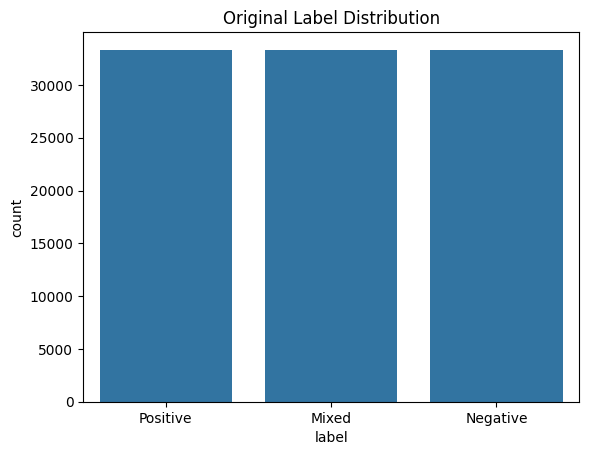

In [ ]:
print(df["label"].value_counts())

sns.countplot(x="label", data=df)
plt.title("Original Label Distribution")
plt.show()

In [ ]:
df = df[df["label"] != "Mixed"]

In [ ]:
df["label"] = df["label"].map({
    "Negative": 0,
    "Positive": 1
})

print(df["label"].value_counts())

label
1    33333
0    33333
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = str(text).strip()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

In [ ]:
df["clean_text"] = df["text"].apply(clean_text)

In [ ]:
df.head()

,label,text,clean_text
0,1,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,1,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,1,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,1,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,1,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)

print(len(train_df), len(test_df))

59999 6667


In [ ]:
train_dataset = Dataset.from_pandas(train_df[["clean_text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["clean_text", "label"]])

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Centralized model
central_model_path = "/content/drive/MyDrive/FASA/final_model"
central_tokenizer = AutoTokenizer.from_pretrained(central_model_path)
central_model = AutoModelForSequenceClassification.from_pretrained(central_model_path)

# Federated model
fl_model_path = "/content/drive/MyDrive/FASA/final_federated_model1round"
fl_tokenizer = AutoTokenizer.from_pretrained(fl_model_path)
fl_model = AutoModelForSequenceClassification.from_pretrained(fl_model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def tokenize_function(example, tokenizer):
    return tokenizer(
        example["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenize for each model separately
central_test = test_dataset.map(lambda x: tokenize_function(x, central_tokenizer), batched=True)
fl_test = test_dataset.map(lambda x: tokenize_function(x, fl_tokenizer), batched=True)

# Set format for PyTorch
central_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
fl_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

NameError: name 'test_dataset' is not defined

In [ ]:
import torch
from torch.utils.data import DataLoader

def get_predictions(model, dataset):
    model.eval()
    dataloader = DataLoader(dataset, batch_size=16)

    preds = []
    labels = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            preds.extend(predictions.cpu().numpy())
            labels.extend(batch["label"].cpu().numpy())

    return preds, labels

In [ ]:
central_preds, y_true = get_predictions(central_model, central_test)
fl_preds, _ = get_predictions(fl_model, fl_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("=== Centralized Model ===")
print("Accuracy:", accuracy_score(y_true, central_preds))
print("F1:", f1_score(y_true, central_preds, average="weighted"))
print(classification_report(y_true, central_preds))

print("\n=== Federated Model ===")
print("Accuracy:", accuracy_score(y_true, fl_preds))
print("F1:", f1_score(y_true, fl_preds, average="weighted"))
print(classification_report(y_true, fl_preds))

=== Centralized Model ===
Accuracy: 0.9098545072746362
F1: 0.9098516557144898
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      3334
           1       0.91      0.90      0.91      3333

    accuracy                           0.91      6667
   macro avg       0.91      0.91      0.91      6667
weighted avg       0.91      0.91      0.91      6667


=== Federated Model ===
Accuracy: 0.9022048897555123
F1: 0.9021785026645579
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      3334
           1       0.89      0.92      0.90      3333

    accuracy                           0.90      6667
   macro avg       0.90      0.90      0.90      6667
weighted avg       0.90      0.90      0.90      6667



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Add numbers inside cells
    for i in range(len(cm)):
        for j in range(len(cm[i])):
            plt.text(j, i, cm[i][j], ha="center", va="center")

    plt.colorbar()
    plt.show()

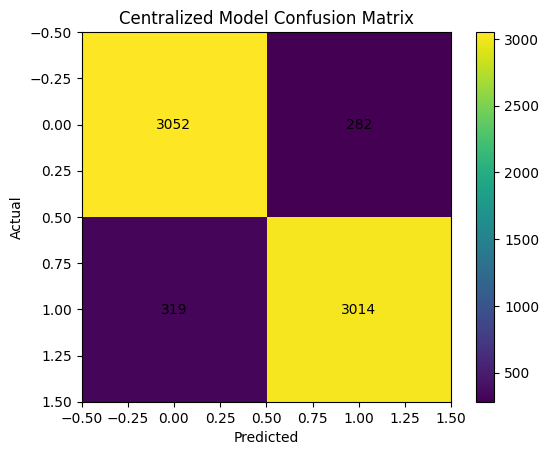

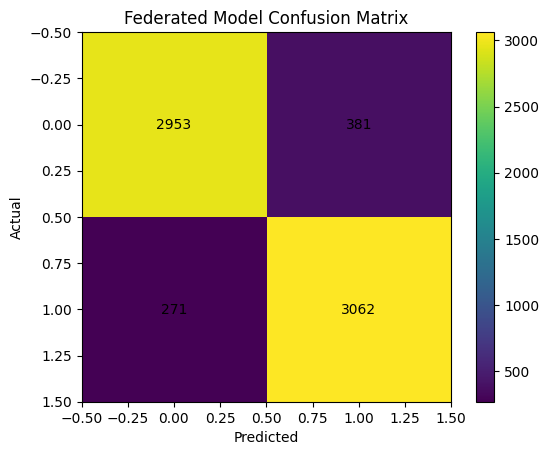

In [ ]:
# Centralized model
plot_confusion_matrix(y_true, central_preds, "Centralized Model Confusion Matrix")

# Federated model
plot_confusion_matrix(y_true, fl_preds, "Federated Model Confusion Matrix")

In [ ]:
import pandas as pd
import re

def load_and_preprocess_ss2030(path):
    """
    Loads SS2030 Arabic sentiment dataset and returns:
    - original_df: basic cleaned text
    - cleaned_df: text without mentions and emojis
    """

    # Load dataset
    df = pd.read_csv(path)

    # 🔍 Inspect columns (adjust if needed)
    print("Columns:", df.columns)

    # Rename columns if needed (ADJUST if your dataset uses different names)
    text_col = "text"
    label_col = "Sentiment"

    # ----------------------------
    # Basic cleaning (common for both)
    # ----------------------------
    def basic_clean(text):
        if pd.isna(text):
            return ""

        text = str(text)

        # Remove URLs
        text = re.sub(r"http\S+|www\S+", "", text)

        # Normalize Arabic letters
        text = re.sub(r"[إأآا]", "ا", text)
        text = re.sub(r"ى", "ي", text)
        text = re.sub(r"ؤ", "و", text)
        text = re.sub(r"ئ", "ي", text)

        # Remove extra spaces
        text = re.sub(r"\s+", " ", text).strip()

        return text

    # ----------------------------
    # Advanced cleaning (remove emojis + mentions)
    # ----------------------------
    def remove_mentions_emojis(text):
        text = str(text)

        # Remove mentions (@user)
        text = re.sub(r"@\w+", "", text)

        # Remove emojis (unicode ranges)
        emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F"  # emoticons
            "\U0001F300-\U0001F5FF"  # symbols
            "\U0001F680-\U0001F6FF"  # transport
            "\U0001F1E0-\U0001F1FF"  # flags
            "]+",
            flags=re.UNICODE
        )
        text = emoji_pattern.sub(r'', text)

        return text

    # ----------------------------
    # Create versions
    # ----------------------------
    df["clean_text_basic"] = df[text_col].apply(basic_clean)

    # Version 1: original (basic cleaning only)
    original_df = df[[ "clean_text_basic", label_col ]].rename(
        columns={"clean_text_basic": "clean_text"}
    )

    # Version 2: remove mentions + emojis
    df["clean_text_full"] = df["clean_text_basic"].apply(remove_mentions_emojis)

    cleaned_df = df[[ "clean_text_full", label_col ]].rename(
        columns={"clean_text_full": "clean_text"}
    )

    # Drop empty rows
    original_df = original_df[original_df["clean_text"].str.strip() != ""]
    cleaned_df = cleaned_df[cleaned_df["clean_text"].str.strip() != ""]

    print("Original size:", len(original_df))
    print("Cleaned size:", len(cleaned_df))

    return original_df, cleaned_df

In [ ]:

df2 = pd.read_csv(path)
df2.columns

Index(['text', 'Sentiment'], dtype='object')

In [ ]:
path = "/content/drive/MyDrive/FASA/Arabic Sentiment Analysis Dataset - SS2030.csv"  # change to your actual file

original_df, cleaned_df = load_and_preprocess_ss2030(path)

print(original_df.head())
print(cleaned_df.head())

Columns: Index(['text', 'Sentiment'], dtype='object')
Original size: 4252
Cleaned size: 4252
                                          clean_text  Sentiment
0                                    حقوق المراة 💚💚💚          1
1        RT @___IHAVENOIDEA: حقوق المراة في الاسلام.          1
2  RT @saud_talep: Retweeted لجنة التنمية بشبرا (...          1
3  RT @MojKsa: حقوق المراة التي تضمنها لها وزارة ...          1
4  RT @abm112211: ولي امر الزوجة او ولي الزوجة او...          1
                                          clean_text  Sentiment
0                                       حقوق المراة           1
1                       RT : حقوق المراة في الاسلام.          1
2  RT : Retweeted لجنة التنمية بشبرا (): ما زال ا...          1
3       RT : حقوق المراة التي تضمنها لها وزارة العدل          1
4  RT : ولي امر الزوجة او ولي الزوجة او ولي المرا...          1


In [ ]:
import torch
from torch.utils.data import DataLoader
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# -----------------------------
# Reusable Functions
# -----------------------------
def tokenize_function(example, tokenizer):
    return tokenizer(
        example["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

def get_predictions(model, dataset,labelname):
    model.eval()
    dataloader = DataLoader(dataset, batch_size=16)

    preds = []
    labels = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            preds.extend(predictions.cpu().numpy())
            labels.extend(batch[labelname].cpu().numpy())

    return preds, labels

def plot_confusion_matrix_labeled(y_true, y_pred, labels_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,5))
    plt.imshow(cm, cmap="viridis")
    plt.title(title)

    plt.xticks(range(len(labels_names)), labels_names, rotation=45)
    plt.yticks(range(len(labels_names)), labels_names)

    for i in range(len(cm)):
        for j in range(len(cm[i])):
            plt.text(j, i, cm[i][j], ha="center", va="center", color="white" if cm[i][j] > cm.max()/2 else "black")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def test_model(model, tokenizer, df,labelname, label_names=["Negative","Positive"]):
    # Convert pandas to HuggingFace Dataset
    test_dataset = Dataset.from_pandas(df[["clean_text", labelname]])

    # Tokenize
    tokenized = test_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)

    # Set format for PyTorch
    tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", labelname])

    # Get predictions
    preds, y_true = get_predictions(model, tokenized,'Sentiment')

    # Metrics
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds, average="weighted")
    report = classification_report(y_true, preds, target_names=label_names)

    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print("Classification Report:\n", report)

    # Confusion Matrix
    plot_confusion_matrix_labeled(y_true, preds, label_names, title="Confusion Matrix")

    return preds, y_true

=== Centralized Model - Original Dataset ===


Map:   0%|          | 0/4252 [00:00<?, ? examples/s]

Accuracy: 0.7004
Weighted F1: 0.6965
Classification Report:
               precision    recall  f1-score   support

    Negative       0.60      0.89      0.72      1816
    Positive       0.87      0.56      0.68      2436

    accuracy                           0.70      4252
   macro avg       0.74      0.72      0.70      4252
weighted avg       0.76      0.70      0.70      4252



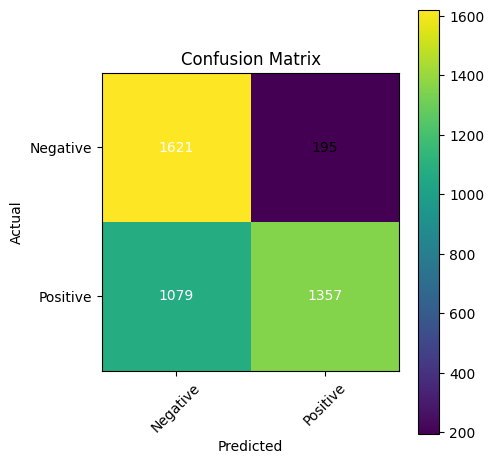

=== Centralized Model - Cleaned Dataset ===


Map:   0%|          | 0/4252 [00:00<?, ? examples/s]

Accuracy: 0.7119
Weighted F1: 0.7101
Classification Report:
               precision    recall  f1-score   support

    Negative       0.61      0.87      0.72      1816
    Positive       0.86      0.59      0.70      2436

    accuracy                           0.71      4252
   macro avg       0.74      0.73      0.71      4252
weighted avg       0.76      0.71      0.71      4252



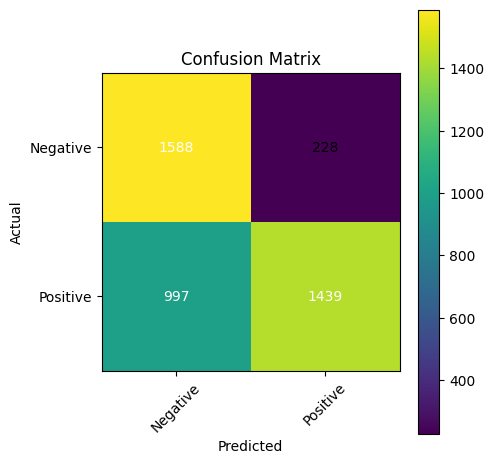

=== Federated Model - Original Dataset ===


Map:   0%|          | 0/4252 [00:00<?, ? examples/s]

Accuracy: 0.7279
Weighted F1: 0.7292
Classification Report:
               precision    recall  f1-score   support

    Negative       0.66      0.74      0.70      1816
    Positive       0.79      0.72      0.75      2436

    accuracy                           0.73      4252
   macro avg       0.72      0.73      0.73      4252
weighted avg       0.73      0.73      0.73      4252



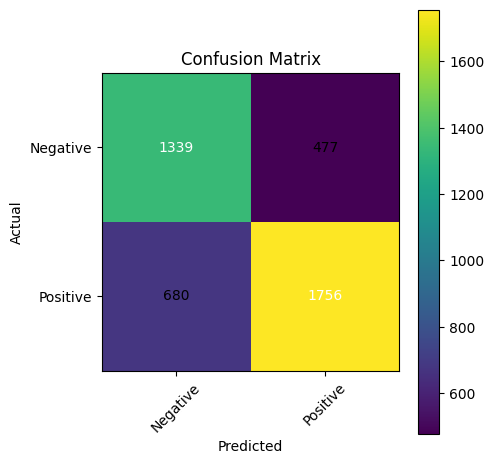

=== Federated Model - Cleaned Dataset ===


Map:   0%|          | 0/4252 [00:00<?, ? examples/s]

Accuracy: 0.7288
Weighted F1: 0.7303
Classification Report:
               precision    recall  f1-score   support

    Negative       0.66      0.77      0.71      1816
    Positive       0.80      0.70      0.75      2436

    accuracy                           0.73      4252
   macro avg       0.73      0.73      0.73      4252
weighted avg       0.74      0.73      0.73      4252



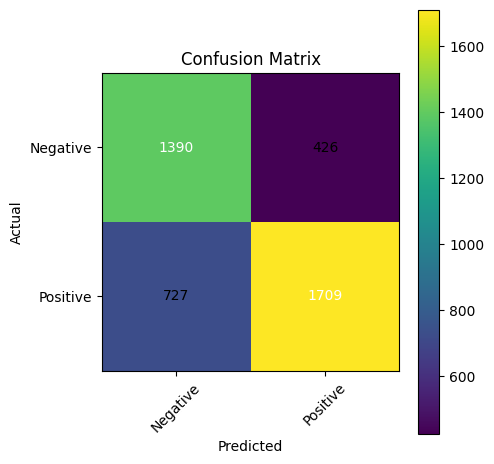

In [ ]:
# Test Centralized Model on original dataset
print("=== Centralized Model - Original Dataset ===")
central_preds_orig, y_true_orig = test_model(central_model, central_tokenizer, original_df,'Sentiment')

# Test Centralized Model on cleaned dataset
print("=== Centralized Model - Cleaned Dataset ===")
central_preds_clean, y_true_clean = test_model(central_model, central_tokenizer, cleaned_df,'Sentiment')

# Test Federated Model on original dataset
print("=== Federated Model - Original Dataset ===")
fl_preds_orig, _ = test_model(fl_model, fl_tokenizer, original_df,'Sentiment')

# Test Federated Model on cleaned dataset
print("=== Federated Model - Cleaned Dataset ===")
fl_preds_clean, _ = test_model(fl_model, fl_tokenizer, cleaned_df,'Sentiment')

In [ ]:
import pandas as pd
import os
import re

def load_merge_preprocess_kaggle(folder_path):
    all_dfs = []

    for file in os.listdir(folder_path):
        if file.endswith(".tsv"):
            file_path = os.path.join(folder_path, file)

            # Load WITHOUT forcing columns
            df = pd.read_csv(file_path, sep="\t", header=None)

            # ----------------------------
            # Handle different structures
            # ----------------------------
            if df.shape[1] == 1:
                df.columns = ["text"]

            elif df.shape[1] >= 2:
                # Usually text is in second column
                df = df.iloc[:, -1]  # take last column
                df = df.to_frame(name="text")

            else:
                continue

            # ----------------------------
            # Assign label from filename
            # ----------------------------
            if "pos" in file.lower():
                df["Sentiment"] = 1
            elif "neg" in file.lower():
                df["Sentiment"] = 0
            else:
                continue

            all_dfs.append(df)

    # Merge all
    merged_df = pd.concat(all_dfs, ignore_index=True)

    print("Merged shape:", merged_df.shape)
    print(merged_df["Sentiment"].value_counts())

    # ----------------------------
    # CLEANING
    # ----------------------------
    def clean_text(text):
        if pd.isna(text):
            return ""

        text = str(text)

        # URLs
        text = re.sub(r"http\S+|www\S+", "", text)

        # Mentions
        text = re.sub(r"@\w+", "", text)

        # Hashtags (#word -> word)
        text = re.sub(r"#", "", text)

        # Emojis
        emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F"
            "\U0001F300-\U0001F5FF"
            "\U0001F680-\U0001F6FF"
            "\U0001F1E0-\U0001F1FF"
            "]+",
            flags=re.UNICODE
        )
        text = emoji_pattern.sub(r'', text)

        # Arabic normalization
        text = re.sub(r"[إأآا]", "ا", text)
        text = re.sub(r"ى", "ي", text)
        text = re.sub(r"ؤ", "و", text)
        text = re.sub(r"ئ", "ي", text)

        # Numbers
        text = re.sub(r"\d+", "", text)

        # Spaces
        text = re.sub(r"\s+", " ", text).strip()

        return text

    merged_df["text"] = merged_df["text"].apply(clean_text)

    # Remove empty rows
    merged_df = merged_df[merged_df["text"] != ""]

    print("Final dataset size:", merged_df.shape)

    return merged_df

In [ ]:
folder_path = "/content/drive/MyDrive/FASA/twiter dataset"

twitter_df = load_merge_preprocess_kaggle(folder_path)
twitter_df['clean_text']=twitter_df['text']
twitter_df.head()

Merged shape: (56795, 2)
Sentiment
1    28513
0    28282
Name: count, dtype: int64
Final dataset size: (56795, 2)


,text,Sentiment,clean_text
0,حتي الايتونز خربتوه مو صاحين انتو؟؟,0,حتي الايتونز خربتوه مو صاحين انتو؟؟
1,واحد تبع النظام السوري يقول ان المخابرات السور...,0,واحد تبع النظام السوري يقول ان المخابرات السور...
2,الي متي التعامل السي للخادمات وعدم احترامهم وك...,0,الي متي التعامل السي للخادمات وعدم احترامهم وك...
3,رايح جاي ي طحلبي الهلال_الاهلي,0,رايح جاي ي طحلبي الهلال_الاهلي
4,تتمغط ومعها سداع,0,تتمغط ومعها سداع


=== Centralized Model - Kaggle Twitter Dataset ===


Map:   0%|          | 0/56795 [00:00<?, ? examples/s]

Accuracy: 0.6179
Weighted F1: 0.6177
Classification Report:
               precision    recall  f1-score   support

    Negative       0.62      0.59      0.61     28282
    Positive       0.61      0.64      0.63     28513

    accuracy                           0.62     56795
   macro avg       0.62      0.62      0.62     56795
weighted avg       0.62      0.62      0.62     56795



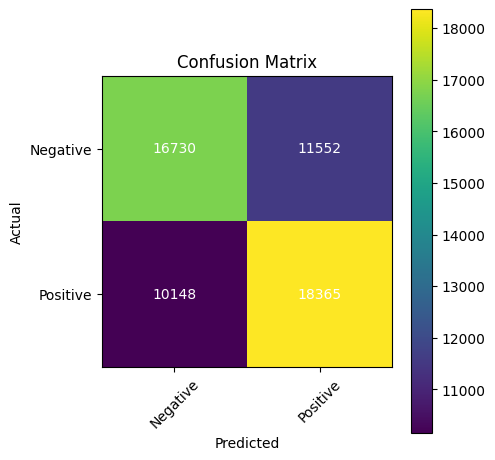

=== Federated Model - Kaggle Twitter Dataset ===


Map:   0%|          | 0/56795 [00:00<?, ? examples/s]

Accuracy: 0.6073
Weighted F1: 0.6011
Classification Report:
               precision    recall  f1-score   support

    Negative       0.64      0.48      0.55     28282
    Positive       0.59      0.73      0.65     28513

    accuracy                           0.61     56795
   macro avg       0.61      0.61      0.60     56795
weighted avg       0.61      0.61      0.60     56795



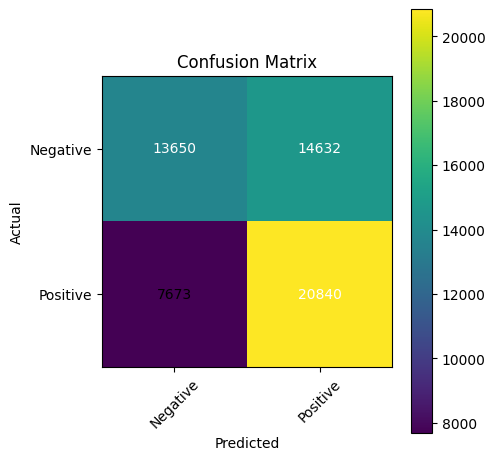

In [ ]:
print("=== Centralized Model - Kaggle Twitter Dataset ===")
central_preds, y_true = test_model(
    central_model,
    central_tokenizer,
    twitter_df,
    'Sentiment'
)

print("=== Federated Model - Kaggle Twitter Dataset ===")
fl_preds, _ = test_model(
    fl_model,
    fl_tokenizer,
    twitter_df,
    'Sentiment'
)